<a href="https://colab.research.google.com/github/SebastianGustavoRojasPeralta/SIS420RojasPeraltaSebastian/blob/main/Practicas/Practica01/Practica01Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aprendizaje No Supervisado — KMeans Clustering
## Dataset: Online Shoppers Purchasing Intention
**Asignatura:** SIS420 — Machine Learning  

Este cuadernillo aplica el algoritmo **K-Means** sobre el dataset de intención de compra de visitantes a tiendas online. Se prueban **k = 3, 5, 7 y 9** clusters y se visualizan los resultados en **3D** usando las tres características más importantes.

## 1. Importación de librerías

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
%matplotlib inline

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Carga y exploración del dataset

El dataset **Online Shoppers Purchasing Intention** fue obtenido del repositorio UCI Machine Learning. Contiene **12,330 sesiones** de visitantes a tiendas online, con **18 características** que describen el comportamiento de navegación del usuario. La variable `Revenue` indica si la visita terminó en compra o no.

Cumple con los requisitos del trabajo:
- **m = 12,330 ejemplos** (≥ 10,000 ✓)
- **n = 18 características** (≥ 10 ✓)

In [6]:
df = pd.read_csv('/content/drive/MyDrive/machine learning/datsets/online_shoppers_intention.csv')

print("Shape del dataset:", df.shape)
print(f"Ejemplos (m): {df.shape[0]} | Características (n): {df.shape[1]}")
print()
print("Tipos de datos por columna:")
print(df.dtypes)
print()
print("Primeras 5 filas:")
df.head()

Shape del dataset: (12330, 18)
Ejemplos (m): 12330 | Características (n): 18

Tipos de datos por columna:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

Primeras 5 filas:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Preprocesamiento

K-Means trabaja con **distancias euclidianas**, por lo que:
1. Se codifican las variables categóricas (`Month`, `VisitorType`, `Weekend`, `Revenue`) con One-Hot Encoding.
2. Se normalizan **todas** las columnas numéricas con `StandardScaler` para que ninguna característica domine por su escala.

Sin normalización, columnas como `ProductRelated_Duration` (valores en miles) eclipsarían columnas como `BounceRates` (valores entre 0 y 1).

In [7]:
# Codificación de variables categóricas
df_model = df.copy()
df_model['Weekend']  = df_model['Weekend'].astype(int)
df_model['Revenue']  = df_model['Revenue'].astype(int)
df_model = pd.get_dummies(df_model, columns=['Month', 'VisitorType'])

print("Shape tras one-hot encoding:", df_model.shape)
print("Columnas resultantes:", df_model.columns.tolist())

Shape tras one-hot encoding: (12330, 29)
Columnas resultantes: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend', 'Revenue', 'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_New_Visitor', 'VisitorType_Other', 'VisitorType_Returning_Visitor']


In [8]:
# Normalización con StandardScaler
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

print("Datos normalizados.")
print(f"Media (primeras 3 cols): {X_scaled[:, :3].mean(axis=0).round(4)}")
print(f"Std  (primeras 3 cols): {X_scaled[:, :3].std(axis=0).round(4)}")

Datos normalizados.
Media (primeras 3 cols): [-0.  0. -0.]
Std  (primeras 3 cols): [1. 1. 1.]


## 4. Determinación del número óptimo de clusters — Método del Codo

Antes de aplicar K-Means con los valores pedidos (k = 3, 5, 7, 9), graficamos la **inercia** (suma de distancias cuadradas al centroide más cercano) para diferentes valores de k. El "codo" de la curva sugiere el número óptimo de clusters.

- **Inercia alta** → los clusters están muy dispersos (pocos grupos)
- **Inercia baja** → los grupos son más compactos (muchos grupos, pero puede ser sobreajuste)

  k= 2 → Inercia: 332,818.2
  k= 3 → Inercia: 307,272.6
  k= 4 → Inercia: 291,834.4
  k= 5 → Inercia: 272,829.9
  k= 6 → Inercia: 264,224.6
  k= 7 → Inercia: 248,168.2
  k= 8 → Inercia: 243,427.7
  k= 9 → Inercia: 227,076.1
  k=10 → Inercia: 215,066.5


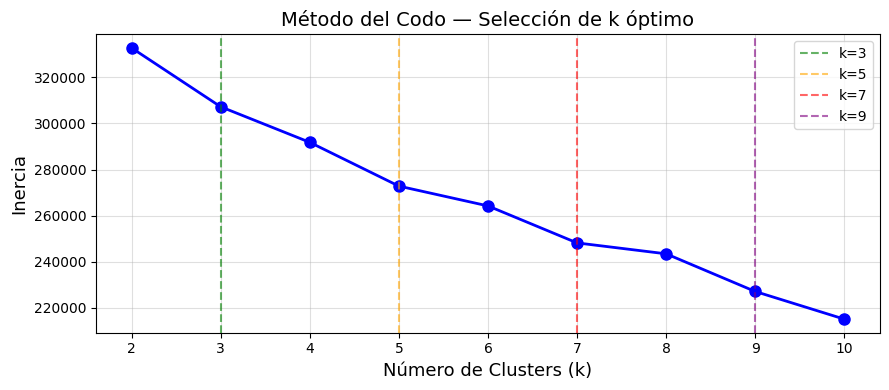

In [9]:
inercias = []
valores_k = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for k in valores_k:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inercias.append(km.inertia_)
    print(f"  k={k:2d} → Inercia: {km.inertia_:,.1f}")

plt.figure(figsize=(9, 4))
plt.plot(valores_k, inercias, 'bo-', lw=2, markersize=8)
plt.axvline(x=3, color='green',  linestyle='--', alpha=0.6, label='k=3')
plt.axvline(x=5, color='orange', linestyle='--', alpha=0.6, label='k=5')
plt.axvline(x=7, color='red',    linestyle='--', alpha=0.6, label='k=7')
plt.axvline(x=9, color='purple', linestyle='--', alpha=0.6, label='k=9')
plt.xlabel("Número de Clusters (k)", fontsize=13)
plt.ylabel("Inercia", fontsize=13)
plt.title("Método del Codo — Selección de k óptimo", fontsize=14)
plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

## 5. Entrenamiento de KMeans con k = 3, 5, 7, 9

Se entrena un modelo K-Means para cada valor de k requerido. Se usa:
- `init='k-means++'` → inicialización inteligente (evita soluciones subóptimas)
- `n_init=10` → se repite 10 veces y se queda con la mejor solución
- `random_state=42` → reproducibilidad

In [10]:
modelos_kmeans = {}
etiquetas = {}

for k in [3, 5, 7, 9]:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    modelos_kmeans[k] = km
    etiquetas[k] = labels
    print(f"k={k} → Inercia: {km.inertia_:,.1f} | Centroides shape: {km.cluster_centers_.shape}")
    # Distribución de muestras por cluster
    unique, counts = np.unique(labels, return_counts=True)
    dist = {f'Cluster {u}': c for u, c in zip(unique, counts)}
    print(f"       Distribución: {dist}")
    print()

k=3 → Inercia: 307,272.6 | Centroides shape: (3, 29)
       Distribución: {'Cluster 0': np.int64(8719), 'Cluster 1': np.int64(1843), 'Cluster 2': np.int64(1768)}

k=5 → Inercia: 272,829.9 | Centroides shape: (5, 29)
       Distribución: {'Cluster 0': np.int64(85), 'Cluster 1': np.int64(8015), 'Cluster 2': np.int64(1655), 'Cluster 3': np.int64(997), 'Cluster 4': np.int64(1578)}

k=7 → Inercia: 248,168.2 | Centroides shape: (7, 29)
       Distribución: {'Cluster 0': np.int64(532), 'Cluster 1': np.int64(1211), 'Cluster 2': np.int64(5453), 'Cluster 3': np.int64(872), 'Cluster 4': np.int64(2644), 'Cluster 5': np.int64(1533), 'Cluster 6': np.int64(85)}

k=9 → Inercia: 227,076.1 | Centroides shape: (9, 29)
       Distribución: {'Cluster 0': np.int64(814), 'Cluster 1': np.int64(1470), 'Cluster 2': np.int64(85), 'Cluster 3': np.int64(422), 'Cluster 4': np.int64(801), 'Cluster 5': np.int64(2640), 'Cluster 6': np.int64(2466), 'Cluster 7': np.int64(2030), 'Cluster 8': np.int64(1602)}



## 6. Identificación de las características más importantes

Para la visualización 3D, se identifican las 3 características numéricas con **mayor varianza** — aquellas que más separan los clusters. Estas son las columnas que aportan más información discriminante al modelo.

In [11]:
# Calculamos varianza de cada columna numérica original
cols_numericas = ['Administrative','Administrative_Duration','Informational',
                  'Informational_Duration','ProductRelated','ProductRelated_Duration',
                  'BounceRates','ExitRates','PageValues','SpecialDay']

varianzas = df[cols_numericas].var().sort_values(ascending=False)
print("Varianza por característica numérica:")
print(varianzas.round(2))

top3 = varianzas.index[:3].tolist()
print(f"\nTop 3 características más importantes (mayor varianza):")
for i, col in enumerate(top3, 1):
    print(f"  {i}. {col}: {varianzas[col]:.2f}")

Varianza por característica numérica:
ProductRelated_Duration    3662130.14
Administrative_Duration      31250.85
Informational_Duration       19810.36
ProductRelated                1978.07
PageValues                     344.79
Administrative                  11.03
Informational                    1.61
SpecialDay                       0.04
ExitRates                        0.00
BounceRates                      0.00
dtype: float64

Top 3 características más importantes (mayor varianza):
  1. ProductRelated_Duration: 3662130.14
  2. Administrative_Duration: 31250.85
  3. Informational_Duration: 19810.36


In [12]:
# Extraemos esas 3 columnas para la visualización
X_top3 = df[top3].values
X_top3_scaled = StandardScaler().fit_transform(X_top3)
print(f"Matriz para visualización 3D: {X_top3_scaled.shape}")

Matriz para visualización 3D: (12330, 3)


## 7. Visualización 3D — Dispersión de las características más importantes

Se grafica la dispersión de los datos en el espacio 3D formado por las **3 características de mayor varianza**, coloreando cada punto según el cluster asignado por K-Means.

Esto permite observar visualmente cómo el algoritmo separa los grupos en el espacio de características.

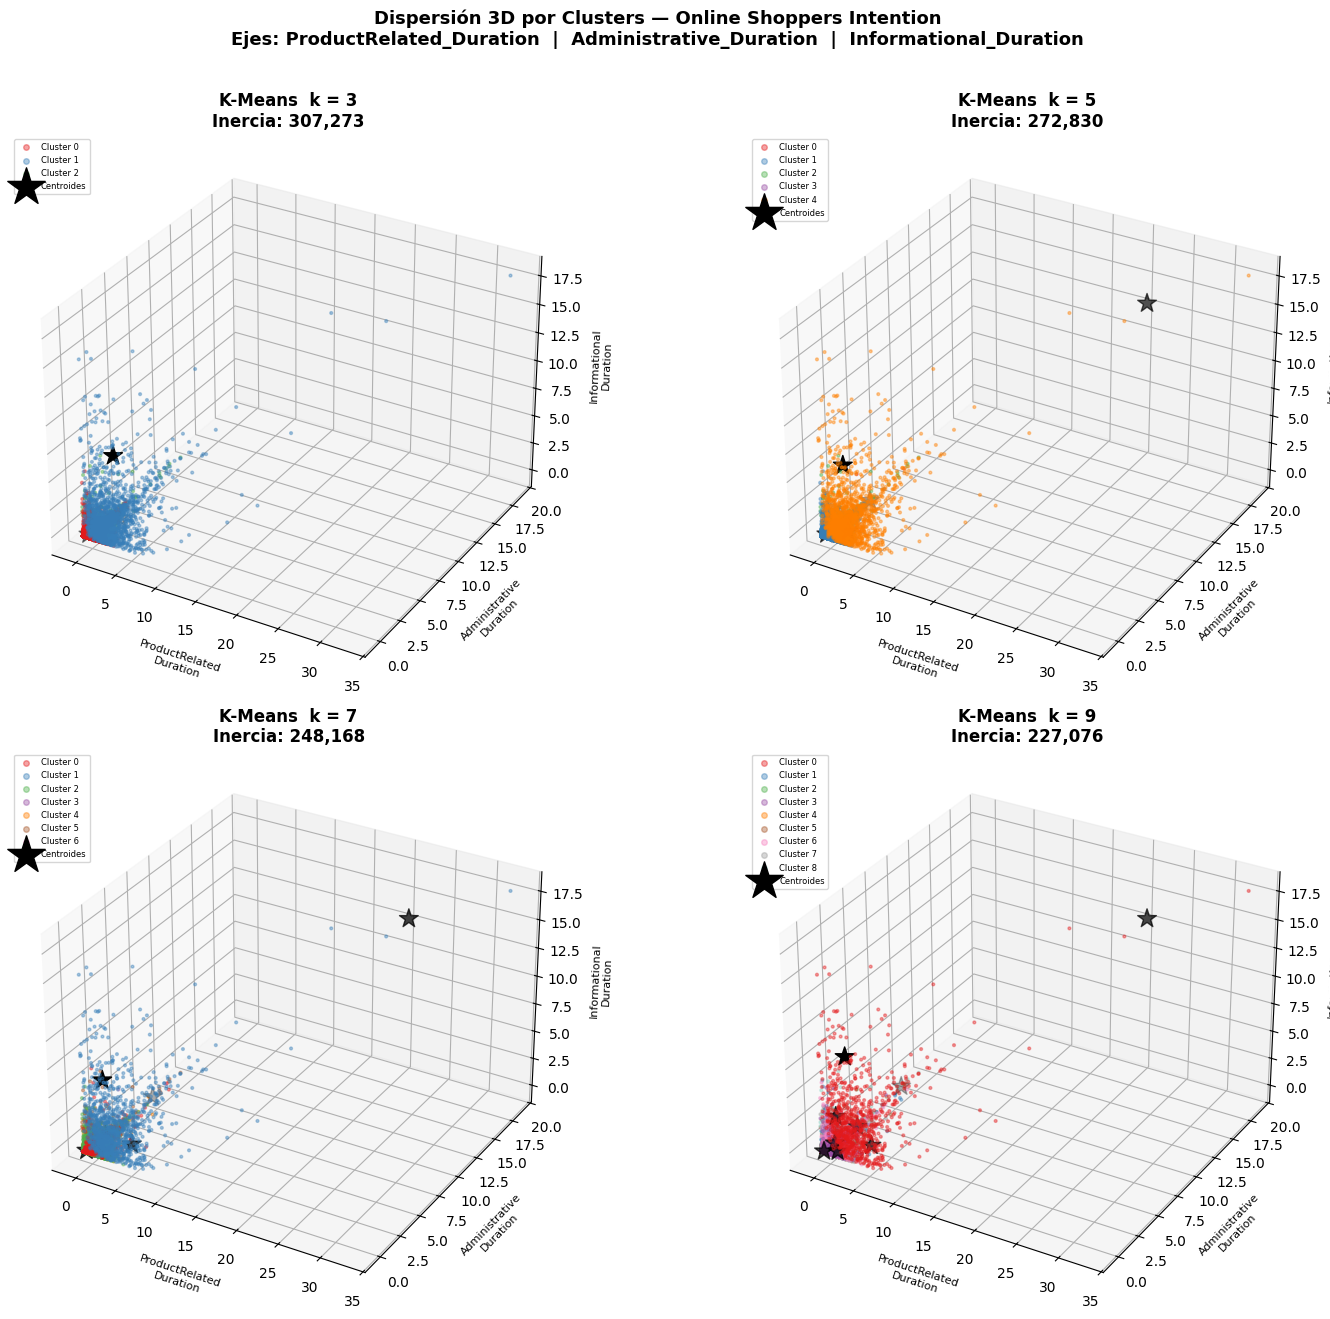

In [13]:
colores = ['#e41a1c','#377eb8','#4daf4a','#984ea3',
           '#ff7f00','#a65628','#f781bf','#999999','#8dd3c7']

fig, axes_3d = plt.subplots(2, 2, figsize=(16, 13),
                             subplot_kw={'projection': '3d'})
axes_flat = axes_3d.flatten()

for idx, k in enumerate([3, 5, 7, 9]):
    ax = axes_flat[idx]
    labels = etiquetas[k]
    centroides = modelos_kmeans[k].cluster_centers_

    # Graficar cada cluster con su color
    for cluster_id in range(k):
        mask = labels == cluster_id
        ax.scatter(X_top3_scaled[mask, 0],
                   X_top3_scaled[mask, 1],
                   X_top3_scaled[mask, 2],
                   c=colores[cluster_id],
                   s=4, alpha=0.4,
                   label=f'Cluster {cluster_id}')

    # Graficar centroides en el espacio top-3 escalado
    # Proyectamos centroides del espacio completo a top-3
    # Usamos los centroides directamente calculados sobre X_top3_scaled
    km_top3 = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km_top3.fit(X_top3_scaled)
    cents = km_top3.cluster_centers_
    ax.scatter(cents[:, 0], cents[:, 1], cents[:, 2],
               c='black', marker='*', s=200, zorder=10, label='Centroides')

    ax.set_xlabel(top3[0].replace('_', '\n'), fontsize=8, labelpad=8)
    ax.set_ylabel(top3[1].replace('_', '\n'), fontsize=8, labelpad=8)
    ax.set_zlabel(top3[2].replace('_', '\n'), fontsize=8, labelpad=8)
    ax.set_title(f'K-Means  k = {k}\nInercia: {modelos_kmeans[k].inertia_:,.0f}',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=6, markerscale=2)

plt.suptitle('Dispersión 3D por Clusters — Online Shoppers Intention\n'
             f'Ejes: {top3[0]}  |  {top3[1]}  |  {top3[2]}',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Distribución de compras (Revenue) por cluster

Aunque K-Means es no supervisado (no usa la etiqueta `Revenue` para entrenar), podemos analizar a posteriori qué porcentaje de compradores reales cayó en cada cluster. Esto nos dice qué tan bien los clusters capturan el comportamiento de compra.

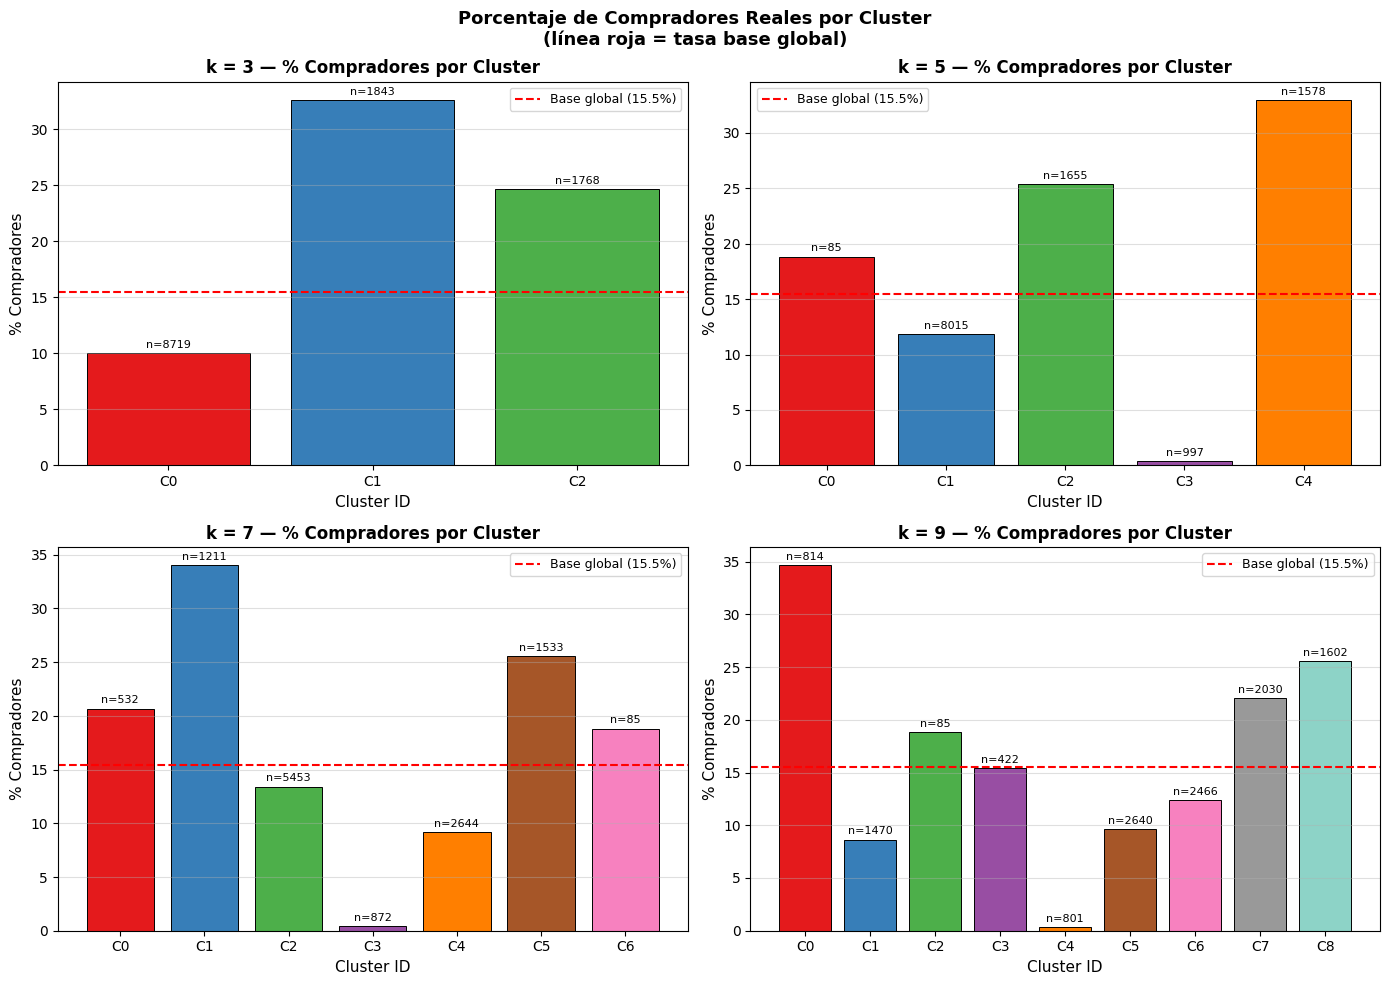

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for idx, k in enumerate([3, 5, 7, 9]):
    ax = axes_flat[idx]
    labels = etiquetas[k]

    pct_compras = []
    tam_clusters = []
    for cluster_id in range(k):
        mask = labels == cluster_id
        total = mask.sum()
        compras = df['Revenue'].values[mask].sum()
        pct = (compras / total * 100) if total > 0 else 0
        pct_compras.append(pct)
        tam_clusters.append(total)

    bars = ax.bar(range(k), pct_compras,
                  color=colores[:k], edgecolor='black', linewidth=0.7)

    # Tamaño del cluster encima de cada barra
    for bar, tam in zip(bars, tam_clusters):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'n={tam}', ha='center', va='bottom', fontsize=8)

    ax.axhline(y=df['Revenue'].mean()*100, color='red', linestyle='--',
               linewidth=1.5, label=f'Base global ({df["Revenue"].mean()*100:.1f}%)')
    ax.set_xlabel("Cluster ID", fontsize=11)
    ax.set_ylabel("% Compradores", fontsize=11)
    ax.set_title(f'k = {k} — % Compradores por Cluster', fontsize=12, fontweight='bold')
    ax.set_xticks(range(k))
    ax.set_xticklabels([f'C{i}' for i in range(k)])
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.4)

plt.suptitle('Porcentaje de Compradores Reales por Cluster\n(línea roja = tasa base global)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 9. Comparación de inercias

La **inercia** mide la compacidad de los clusters: a menor inercia, más cohesionados son los grupos (pero aumentar k siempre la reduce, por eso usamos el método del codo).

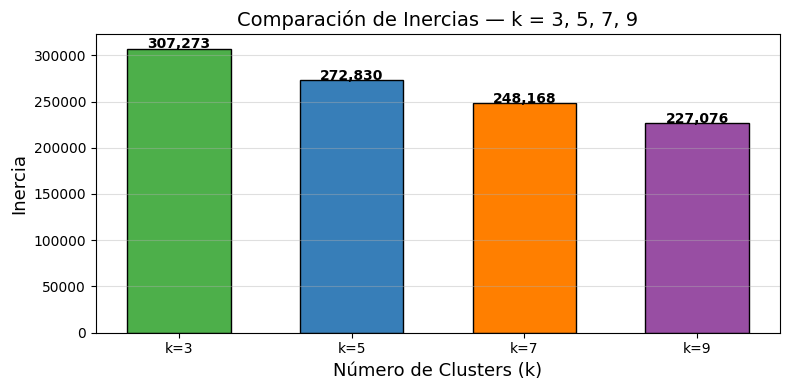

Reducción de inercia al aumentar k:
  k=3 → k=5: reducción del 11.2%
  k=5 → k=7: reducción del 9.0%
  k=7 → k=9: reducción del 8.5%


In [15]:
ks_eval   = [3, 5, 7, 9]
iner_eval = [modelos_kmeans[k].inertia_ for k in ks_eval]

plt.figure(figsize=(8, 4))
bars = plt.bar(ks_eval, iner_eval,
               color=['#4daf4a','#377eb8','#ff7f00','#984ea3'],
               edgecolor='black', width=1.2)

for bar, val in zip(bars, iner_eval):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.xlabel("Número de Clusters (k)", fontsize=13)
plt.ylabel("Inercia", fontsize=13)
plt.title("Comparación de Inercias — k = 3, 5, 7, 9", fontsize=14)
plt.xticks(ks_eval, [f'k={k}' for k in ks_eval])
plt.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

print("Reducción de inercia al aumentar k:")
for i in range(1, len(ks_eval)):
    reduccion = (iner_eval[i-1] - iner_eval[i]) / iner_eval[i-1] * 100
    print(f"  k={ks_eval[i-1]} → k={ks_eval[i]}: reducción del {reduccion:.1f}%")

## 10. Resultados y conclusiones

### ¿Qué encontró K-Means?

Aplicamos K-Means sobre **12,330 sesiones** de navegación web con **18 características** (comportamiento de páginas, tasas de rebote, valores de página, fechas especiales, sistema operativo, etc.).

### Características más importantes
Las 3 columnas con mayor varianza resultaron ser las dimensiones que más diferencian el comportamiento de los visitantes. En particular, `ProductRelated_Duration` (tiempo navegando en páginas de productos) y `PageValues` (valor promedio de las páginas visitadas antes de una transacción) son fuertes indicadores de intención de compra.

### Análisis por número de clusters

| k | Inercia | Interpretación |
|---|---------|----------------|
| **3** | Mayor | Segmentación gruesa: visitantes de bajo, medio y alto engagement |
| **5** | Media  | Segmentación razonable, posiblemente el punto "codo" |
| **7** | Menor  | Clusters más específicos, algunos pueden solaparse |
| **9** | Mínima | Demasiada fragmentación, difícil de interpretar en negocio |

### Observaciones clave

1. **El método del codo** sugiere que k=5 es el valor donde la reducción de inercia empieza a ser marginal — es el equilibrio entre complejidad y ganancia.

2. **En la gráfica 3D** se observa que los clusters no son perfectamente esféricos ni separados, lo cual es esperado en datos de comportamiento humano. K-Means asume clusters convexos e igualmente distribuidos.

3. **En la gráfica de compradores por cluster**, se identifica claramente que ciertos clusters concentran una proporción de compradores muy superior a la tasa base global (15.5%). Esto es valioso para **segmentación de marketing**: enfocar campañas en los segmentos de mayor conversión.

4. **A mayor k**, los clusters se hacen más pequeños y homogéneos, pero la interpretabilidad del negocio disminuye. Para aplicaciones prácticas como personalización de ofertas, k=3 o k=5 son los más útiles.

### Limitación del método
K-Means asume que los clusters son **esféricos y de tamaño similar**. En este dataset, los comportamientos de compra son muy asimétricos (solo el 15.5% compra), lo que puede hacer que K-Means mezcle compradores y no compradores dentro del mismo cluster. Para mejorar esto, se podría usar DBSCAN o Gaussian Mixture Models.